In [1]:
from collections import deque
import numpy as np

class KalmanFilter:
    """
    At the begining of the development of MPC, I could not decide whether to proceed with KF or MSE.
    """

    def __init__(self, init_guess, measurement_covar, A, B, C, init_u, state_noise_covar=None, estim_err_covar=None):
        self.posteriori_state_estim = init_guess
        self.measurement_covar = measurement_covar # This will be the R_k, which is the covariance of nu_k which represent the Gaussian zero-mean white noise in measurement noise
        if state_noise_covar is None:
            self.state_noise_covar = state_noise_covar # This will be the Q_k, the covariance of w_k which represent the Gaussian zero-mean white noise in the state propagation system
        else:
            self.state_noise_covar = np.array([0])
        if estim_err_covar is None:
            self.posteriori_estim_err_covar = np.diag(np.full(init_guess.shape[0], np.inf)) # This will be the P_k, the estimation-error covariance
        else:
            self.posteriori_estim_err_covar = estim_err_covar
        self.A = A #F
        self.B = B #G
        self.C = C #H

        self.u_storage = deque([init_u.item()], maxlen=2)
    
    def is_symmetric_positive_definite(P, symmetry_tol=1e-6):
        P = np.asarray(P)

        # Check square
        if P.ndim != 2 or P.shape[0] != P.shape[1]:
            return False

        # Check symmetry
        if not np.allclose(P, P.T, atol=symmetry_tol):
            return False

        # Check positive definiteness
        try:
            np.linalg.cholesky(P)
            return True
        except np.linalg.LinAlgError:
            return False

    def state_estim(self, new_measurement, u):
        """
        The update function is designed to be used for k>=1. Therefore, for the k=0 (the initial time step) there is no such thing as state propagation to do. Thus, it is just the initial guess have to be used.
        """
        self.u_storage.append(u.item())
        self.priori_estim_err_covar = self.A@self.posteriori_estim_err_covar@self.A.T + self.state_noise_covar
        temporary_matrix = self.A@self.priori_estim_err_covar@self.A.T + self.measurement_covar
        temporary_matrix_inverse = temporary_matrix.inv
        self.gain = self.priori_estim_err_covar@self.A.T@temporary_matrix_inverse
        self.priori_state_estim = self.A@self.posteriori_state_estim + self.B@self.u_storage[0]
        self.posteriori_state_estim = self.priori_state_estim + self.gain@(new_measurement - self.C@self.priori_state_estim)
        kh = self.gain@self.C
        self.posteriori_estim_err_covar = (np.eye(kh.shape[0]) - kh)@self.priori_estim_err_covar
        if not self.is_symmetric_positive_definite(self.posteriori_estim_err_covar):
            self.posteriori_estim_err_covar = (np.eye(kh.shape[0]) - kh)@self.priori_estim_err_covar@(np.eye(kh.shape[0]) - kh).T + self.gain@self.measurement_covar@self.gain.T
        return self.posteriori_state_estim

In [2]:
from collections import deque
import numpy as np


class KalmanFilter:
    def __init__(
        self,
        init_guess,
        measurement_covar,
        A,
        B,
        C,
        init_u,
        state_noise_covar=None,
        estim_err_covar=None,
    ):
        self.posteriori_state_estim = np.asarray(init_guess, dtype=float).reshape(-1, 1)

        self.A = np.asarray(A, dtype=float)
        self.B = np.asarray(B, dtype=float)
        self.C = np.asarray(C, dtype=float)

        n = self.A.shape[0]
        m = self.C.shape[0]

        self.measurement_covar = np.asarray(measurement_covar, dtype=float).reshape(m, m)

        if state_noise_covar is None:
            self.state_noise_covar = np.zeros((n, n))
        else:
            self.state_noise_covar = np.asarray(state_noise_covar, dtype=float).reshape(n, n)

        if estim_err_covar is None:
            # Avoid np.inf. Use a large finite covariance instead.
            self.posteriori_estim_err_covar = np.eye(n) * 1e6
        else:
            self.posteriori_estim_err_covar = np.asarray(estim_err_covar, dtype=float).reshape(n, n)

        self.u_storage = deque(
            [np.asarray(init_u, dtype=float).reshape(-1, 1)],
            maxlen=2,
        )

        # Diagnostics
        self.innovation_history = []
        self.S_history = []
        self.nis_history = []
        self.P_is_spd_history = []

    @staticmethod
    def is_symmetric_positive_definite(P, symmetry_tol=1e-6):
        P = np.asarray(P)

        # Check square
        if P.ndim != 2 or P.shape[0] != P.shape[1]:
            return False

        # Check symmetry
        if not np.allclose(P, P.T, atol=symmetry_tol):
            return False

        # Check positive definiteness
        try:
            np.linalg.cholesky(P)
            return True
        except np.linalg.LinAlgError:
            return False

    def state_estimation(self, new_measurement, u):
        y = np.asarray(new_measurement, dtype=float).reshape(self.C.shape[0], 1)
        u = np.asarray(u, dtype=float).reshape(self.B.shape[1], 1)

        # Store current input.
        self.u_storage.append(u)
        u_prev = self.u_storage[0]

        # 1. A priori prediction
        self.priori_state_estim = self.A @ self.posteriori_state_estim + self.B @ u_prev
        self.priori_estim_err_covar = self.A @ self.posteriori_estim_err_covar @ self.A.T + self.state_noise_covar

        # 2. Innovation
        innovation = y - self.C @ self.priori_state_estim
        S = self.C @ self.priori_estim_err_covar @ self.C.T + self.measurement_covar
        asymmetry = np.linalg.norm(S - S.T)
        if asymmetry > 1e-8:
            print("Warning: S is noticeably asymmetric:", asymmetry)
        S = 0.5 * (S + S.T)
        # S is the innovation covariance matrix. Analytically, it should be symmetric so we took the numerical symmetrization step here.

        # 3. Kalman gain
        # self.gain = self.priori_estim_err_covar @ self.C.T @ np.linalg.inv(S). Computation of inverse matrix is slow and fragile. In fact, solving linear algebra is more stable than computing inverse matrix.
        PCt = self.priori_estim_err_covar @ self.C.T
        self.gain = np.linalg.solve(S.T, PCt.T).T

        # 4. A posteriori state update
        self.posteriori_state_estim = self.priori_state_estim + self.gain @ innovation

        # 5. A posteriori estimation-error covariance update
        I = np.eye(self.posteriori_estim_err_covar.shape[0])
        I_KC = I - self.gain @ self.C
        # initially use the computationally simple version
        self.posteriori_estim_err_covar = I_KC @ self.priori_estim_err_covar
        # check if the covariance is positive definite. if failed, recalculate estimation-error covariance using Joseph stabilized form
        if self.is_symmetric_positive_definite(self.posteriori_estim_err_covar):
            pass
        else:
            self.posteriori_estim_err_covar = I_KC @ self.priori_estim_err_covar @ I_KC.T + self.gain @ self.measurement_covar @ self.gain.T
        if not self.is_symmetric_positive_definite(self.posteriori_estim_err_covar):
            print("Warning: posterior covariance P is not semmetric positive-definite even after Joseph update.")
        self.posteriori_estim_err_covar = 0.5 * (self.posteriori_estim_err_covar + self.posteriori_estim_err_covar.T)

        # 6. Diagnostics
        L = np.linalg.cholesky(S)
        normalized_innovation = np.linalg.solve(L, innovation)
        nis = (normalized_innovation.T @ normalized_innovation).item()

        self.innovation_history.append(innovation.copy())
        self.S_history.append(S.copy())
        self.nis_history.append(nis)
        self.P_is_spd_history.append(
            self.is_symmetric_positive_definite(self.posteriori_estim_err_covar)
        )

        return self.posteriori_state_estim

In [3]:
class toysys:
    def __init__(
        self,
        init_x,
        A,
        B,
        C,
        D,
        measurement_noise_std,
        state_noise_std,
    ):
        self.A = A
        self.B = B
        self.C = C
        self.D = D
        self.state = init_x
        self.measurement_noise_std = measurement_noise_std
        self.state_noise_std = state_noise_std

    def step(self, u):
        observation = self.C @ self.state + self.D @ u

        nu = np.random.normal(
            loc=0.0,
            scale=self.measurement_noise_std,
            size=observation.shape,
        )

        observation = observation + nu

        self.state = self.A @ self.state + self.B @ u

        w = np.random.normal(
            loc=0.0,
            scale=self.state_noise_std,
            size=self.state.shape,
        )

        self.state = self.state + w

        return observation

In [4]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(0)

# ------------------------------------------------------------
# Simple 1D system:
#
# x_{k+1} = x_k + u_k + w_k
# y_k     = x_k + v_k
# ------------------------------------------------------------

A = np.array([[1.0]])
B = np.array([[1.0]])
C = np.array([[1.0]])
D = np.array([[0.0]])

measurement_noise_std = 0.5
state_noise_std = 0.05

R = np.array([[measurement_noise_std**2]])
Q = np.array([[state_noise_std**2]])

x0_true = np.array([[0.0]])

# Intentionally wrong initial estimate.
x0_guess = np.array([[3.0]])

# Initial estimation-error covariance.
P0 = np.array([[10.0]])

init_u = np.array([[0.0]])

plant = toysys(
    init_x=x0_true.copy(),
    A=A,
    B=B,
    C=C,
    D=D,
    measurement_noise_std=measurement_noise_std,
    state_noise_std=state_noise_std,
)

kf = KalmanFilter(
    init_guess=x0_guess,
    measurement_covar=R,
    A=A,
    B=B,
    C=C,
    init_u=init_u,
    state_noise_covar=Q,
    estim_err_covar=P0,
)

num_steps = 300

true_history = []
measurement_history = []
estimate_history = []
control_history = []

# ------------------------------------------------------------
# Important timing detail:
#
# toysys.step(u_k) returns measurement of the current state x_k,
# then propagates the plant to x_{k+1}.
#
# Therefore, before calling plant.step(), we store the current
# true state for comparison.
# ------------------------------------------------------------

# Warm-up step: creates x_1 from x_0.
u0 = np.array([[0.0]])
_ = plant.step(u0)

for k in range(1, num_steps + 1):
    # Current true state x_k, before the plant moves to x_{k+1}
    true_x_k = plant.state.copy()

    # Current input u_k, which will be used by the plant to move to x_{k+1}
    u_k = np.array([[0.1 * np.sin(0.05 * k)]])

    # Measurement y_k of current state x_k.
    # After this call, plant.state becomes x_{k+1}.
    y_k = plant.step(u_k)

    # KF estimates x_k using y_k.
    # Internally, the KF uses the previous input to predict x_k.
    xhat_k = kf.state_estimation(y_k, u_k)

    true_history.append(true_x_k.item())
    measurement_history.append(y_k.item())
    estimate_history.append(xhat_k.item())
    control_history.append(u_k.item())


true_history = np.array(true_history)
measurement_history = np.array(measurement_history)
estimate_history = np.array(estimate_history)
control_history = np.array(control_history)

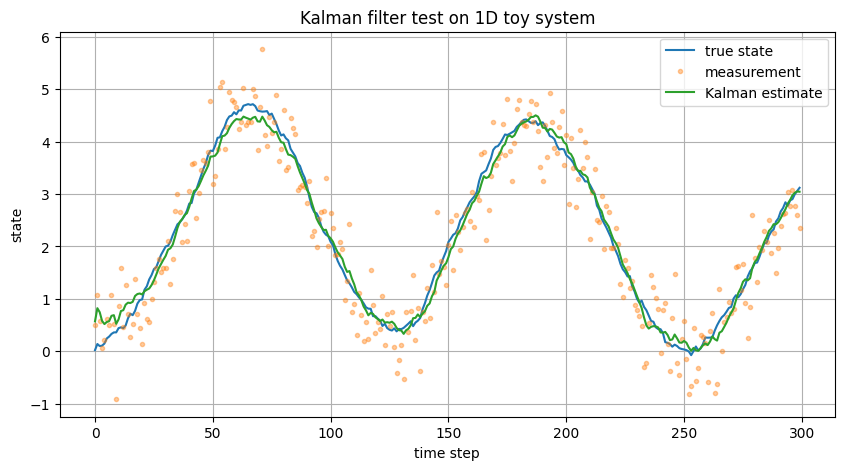

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(true_history, label="true state")
plt.plot(measurement_history, ".", alpha=0.4, label="measurement")
plt.plot(estimate_history, label="Kalman estimate")
plt.xlabel("time step")
plt.ylabel("state")
plt.title("Kalman filter test on 1D toy system")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
burn_in = 30

estimation_error = estimate_history - true_history
measurement_error = measurement_history - true_history

estimation_rmse = np.sqrt(np.mean(estimation_error[burn_in:] ** 2))
measurement_rmse = np.sqrt(np.mean(measurement_error[burn_in:] ** 2))

innov = np.array(kf.innovation_history)
S_vals = np.array(kf.S_history)
nis = np.array(kf.nis_history)

innovation_mean = np.mean(innov[burn_in:])
innovation_std = np.std(innov[burn_in:])
average_predicted_innovation_std = np.mean(np.sqrt(S_vals[burn_in:]))
average_nis = np.mean(nis[burn_in:])

print("Measurement RMSE:")
print(measurement_rmse)

print("\nKalman estimate RMSE:")
print(estimation_rmse)

print("\nInnovation mean after burn-in:")
print(innovation_mean)

print("\nInnovation std after burn-in:")
print(innovation_std)

print("\nAverage predicted innovation std sqrt(S):")
print(average_predicted_innovation_std)

print("\nAverage NIS:")
print(average_nis)

print("\nExpected average NIS:")
print(1.0)

print("\nFinal posterior covariance P:")
print(kf.posteriori_estim_err_covar)

print("\nWas P symmetric positive definite at every step?")
print(all(kf.P_is_spd_history))

Measurement RMSE:
0.5016676832704112

Kalman estimate RMSE:
0.13865339411299135

Innovation mean after burn-in:
-0.014710775941781117

Innovation std after burn-in:
0.5274155283003904

Average predicted innovation std sqrt(S):
0.5256270197118961

Average NIS:
1.0076021414310696

Expected average NIS:
1.0

Final posterior covariance P:
[[0.02378123]]

Was P symmetric positive definite at every step?
True


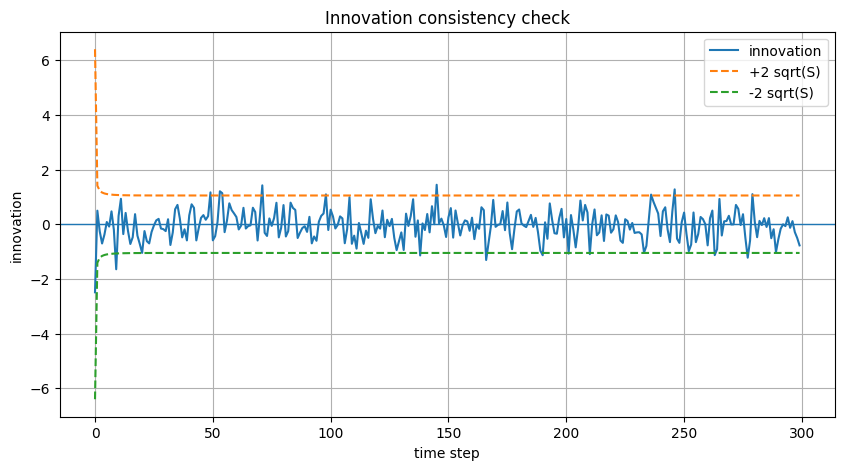

In [7]:
innov = np.array(kf.innovation_history).reshape(-1)
S_vals = np.array(kf.S_history).reshape(-1)

std_vals = np.sqrt(S_vals)

plt.figure(figsize=(10, 5))
plt.plot(innov, label="innovation")
plt.plot(2 * std_vals, "--", label="+2 sqrt(S)")
plt.plot(-2 * std_vals, "--", label="-2 sqrt(S)")
plt.axhline(0.0, linewidth=1)
plt.xlabel("time step")
plt.ylabel("innovation")
plt.title("Innovation consistency check")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
def check_kf_performance(
    measurement_rmse,
    estimation_rmse,
    innovation_mean,
    innovation_std,
    average_predicted_innovation_std,
    average_nis,
    P_spd_all_steps,
):
    print("\n========== KF CHECK ==========")

    if estimation_rmse < measurement_rmse:
        print("PASS: KF estimate is better than raw measurement.")
    else:
        print("FAIL: KF estimate is not better than raw measurement.")

    if abs(innovation_mean) < 0.1:
        print("PASS: innovation mean is close to zero.")
    else:
        print("WARNING: innovation mean is not close to zero.")

    ratio = innovation_std / average_predicted_innovation_std

    if 0.7 < ratio < 1.3:
        print("PASS: innovation std is consistent with predicted sqrt(S).")
    else:
        print("WARNING: innovation std is not consistent with predicted sqrt(S).")

    if 0.5 < average_nis < 1.5:
        print("PASS: average NIS is close to expected value 1.")
    else:
        print("WARNING: average NIS is far from expected value 1.")

    if P_spd_all_steps:
        print("PASS: posterior covariance P stayed symmetric positive definite.")
    else:
        print("FAIL: posterior covariance P was not SPD at every step.")

    print("================================")


check_kf_performance(
    measurement_rmse=measurement_rmse,
    estimation_rmse=estimation_rmse,
    innovation_mean=innovation_mean,
    innovation_std=innovation_std,
    average_predicted_innovation_std=average_predicted_innovation_std,
    average_nis=average_nis,
    P_spd_all_steps=all(kf.P_is_spd_history),
)


========== KF CHECK ==========
PASS: KF estimate is better than raw measurement.
PASS: innovation mean is close to zero.
PASS: innovation std is consistent with predicted sqrt(S).
PASS: average NIS is close to expected value 1.
PASS: posterior covariance P stayed symmetric positive definite.


In [9]:
import casadi as ca
import numpy as np

# -----------------------------
# Problem settings
# -----------------------------
N = 20
T = 10.0
dt = T / N

# -----------------------------
# Define model and integrator
# -----------------------------
x = ca.MX.sym("x", 2)
u = ca.MX.sym("u")

xdot = ca.vertcat(
    (1 - x[1]**2) * x[0] - x[1] + u,
    x[0]
)

L = x[0]**2 + x[1]**2 + u**2

dae = {
    "x": x,
    "p": u,
    "ode": xdot,
    "quad": L
}

F = ca.integrator(
    "F",
    "cvodes",
    dae,
    {
        "tf": dt
    }
)

# -----------------------------
# Build NLP
# -----------------------------
w = []
g = []
J = 0

# Initial state parameter
X0 = ca.MX.sym("X0", 2)

Xk = X0

for k in range(N):
    # Control variable
    Uk = ca.MX.sym(f"U_{k}")
    w.append(Uk)

    # Integrate system over one interval
    Fk = F(x0=Xk, p=Uk)
    Xk_end = Fk["xf"]
    J = J + Fk["qf"]

    # State variable at end of interval
    Xk = ca.MX.sym(f"X_{k+1}", 2)
    w.append(Xk)

    # Multiple-shooting continuity constraint
    g.append(Xk_end - Xk)

# Stack optimization variables and constraints
w = ca.vertcat(*w)
g = ca.vertcat(*g)

# NLP problem
prob = {
    "f": J,
    "x": w,
    "g": g,
    "p": X0
}

# Solver
solver = ca.nlpsol("solver", "ipopt", prob)

# -----------------------------
# Solve once
# -----------------------------
x0_measured = np.array([0.0, 1.0])

w0 = np.zeros(w.shape[0])
lbg = np.zeros(g.shape[0])
ubg = np.zeros(g.shape[0])

sol = solver(
    x0=w0,
    lbg=lbg,
    ubg=ubg,
    p=x0_measured
)

w_opt = sol["x"]

print("Optimal decision vector:")
print(w_opt)

print("First control input:")
print(float(w_opt[0]))


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      156
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      115

Total number of variables............................:       60
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       40
Total number of inequality c

CasADi - 2026-06-16 14:29:06 WARNING("The options 't0', 'tf', 'grid' and 'output_t0' have been deprecated.
The same functionality is provided by providing additional input arguments to the 'integrator' function, in particular:
 * Call integrator(..., t0, tf, options) for a single output time, or
 * Call integrator(..., t0, grid, options) for multiple grid points.
The legacy 'output_t0' option can be emulated by including or excluding 't0' in 'grid'.
Backwards compatibility is provided in this release only.") [.../casadi/core/integrator.cpp:692]
